#### **CLASIFFIER DOGS VS CATS**

#### Sistema de clasificación de imágenes ####

El conjunto de datos se compone de fotos de perros y gatos proporcionadas como un subconjunto de fotos de uno mucho más grande de 3 millones de fotos anotadas manualmente. Estos datos se obtuvieron a través de una colaboración entre Petfinder.com y Microsoft.

El conjunto de datos se usó originalmente como un CAPTCHA, es decir, una tarea que se cree que un humano encuentra trivial, pero que una máquina no puede resolver, que se usa en sitios web para distinguir entre usuarios humanos y bots. La tarea se denominó "Asirra". Cuando se presentó "Asirra", se mencionó "que los estudios de usuarios indican que los humanos pueden resolverlo el 99,6% de las veces en menos de 30 segundos". A menos que se produzca un gran avance en la visión artificial, esperamos que los ordenadores no tengan más de 1/54.000 posibilidades de resolverlo.

En el momento en que se publicó la competencia, el resultado de última generación se logró con un SVM y se describió en un artículo de 2007 con el título "Ataques de Machine Learning contra el CAPTCHA de Asirra" (PDF) que logró una precisión de clasificación del 80%. Fue este documento el que demostró que la tarea ya no era una tarea adecuada para un CAPTCHA poco después de que se propusiera la tarea.

In [46]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import keras_tuner as kt
import pickle

#### Load the selection images: ####

In [30]:
# Exploramos el contenido
ruta_base = "../../data/dogs-vs-cats"

def contar_jpg(ruta):
    return len([f for f in os.listdir(ruta) if f.lower().endswith('.jpg')]) if os.path.isdir(ruta) else 0

for root, dirs, files in os.walk(ruta_base):
    nivel = root.replace(ruta_base, '').count(os.sep)
    sangria = '  ' * nivel
    nombre_carpeta = os.path.basename(root)
    total_jpg = contar_jpg(root)
    print(f"{sangria}{nombre_carpeta}/ ({total_jpg} imágenes)")

#### Image visualization ####

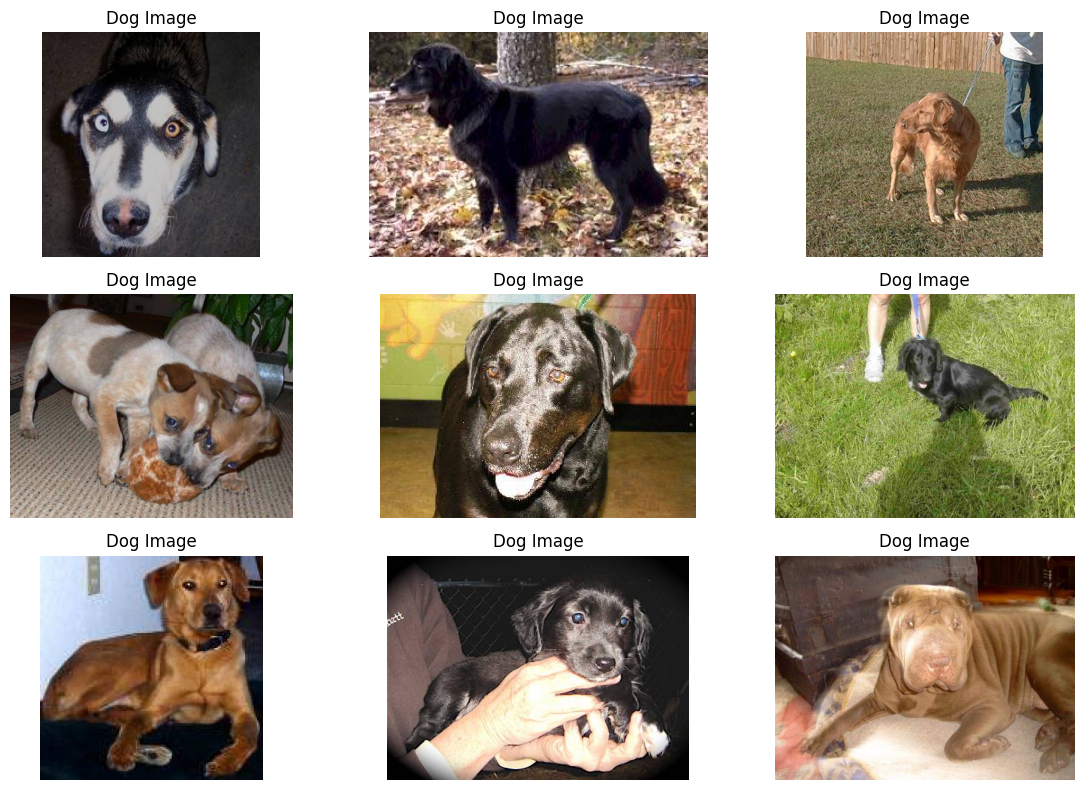

In [ ]:
# Path to the directory containing your image data
data_dir = "../data/dogs-vs-cats/train"

# Get a list of all dog image file names
dog_subfolder = os.path.join(data_dir, "dog")

# Get a list of all dog image file names
dog_image_files = os.listdir(dog_subfolder)

# Load the first nine dog images
dog_images = []
for i in range(9):
    img_path = os.path.join(dog_subfolder, dog_image_files[i])
    img = image.load_img(img_path)  # Adjust target_size as needed
    img_array = image.img_to_array(img)
    img_array /= 255.0  # Normalize pixel values to [0, 1]
    dog_images.append(img_array)

# Create a single figure to display all nine images
plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(dog_images[i])
    plt.title('Dog Image')
    plt.axis('off')

# Adjust Layout
plt.tight_layout()

# Show the pictures
plt.show()

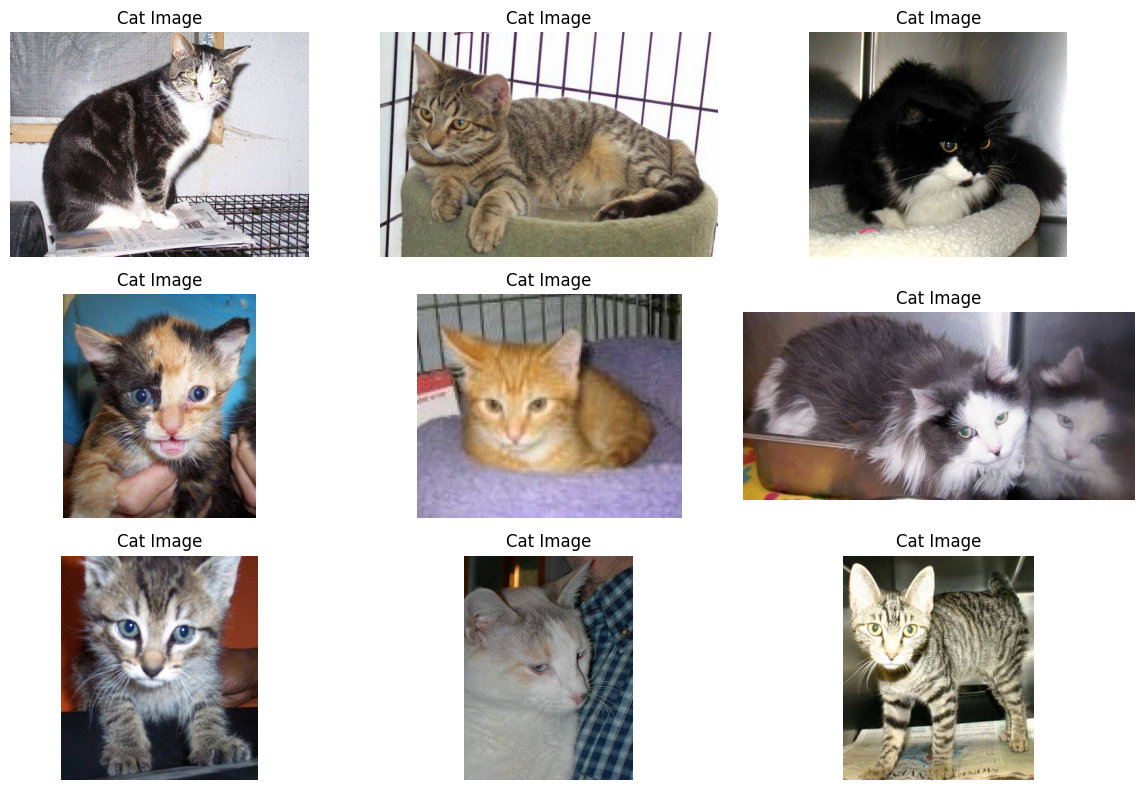

In [ ]:
# Path to the directory containing your image data
data_dir = "../data/dogs-vs-cats/train"

# Get a list of all cat image file names
cats_subfolder = os.path.join(data_dir, "cat")

# Get a list of all Cat image file names
cats_image_files = os.listdir(cats_subfolder)

# Load the first nine cat images
cats_images = []
for i in range(min(9, len(cats_image_files))):  # Limit to available cat images
    img_path = os.path.join(cats_subfolder, cats_image_files[i])
    img = image.load_img(img_path)
    img_array = image.img_to_array(img)
    img_array /= 255.0
    cats_images.append(img_array)

# Create a single figure to display all cat images
plt.figure(figsize=(12, 8))

for i in range(len(cats_images)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(cats_images[i])
    plt.title('Cat Image')
    plt.axis('off')

# Adjust Layout
plt.tight_layout()

# Show the pictures
plt.show()

#### We make sure that all images are 200x200. ####

In [ ]:
#SizeChange
IMG_SIZE = (200, 200)

trdata = ImageDataGenerator(rescale=1./255)
tsdata = ImageDataGenerator(rescale=1./255)

train_data = trdata.flow_from_directory(r"../data/dogs-vs-cats/train",
                                        target_size=(IMG_SIZE),
                                        batch_size=32,
                                        class_mode='binary')

test_data = tsdata.flow_from_directory(r"../data/dogs-vs-cats/test",target_size=(IMG_SIZE),
                                       batch_size=32,
                                       class_mode='binary')

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


## RNA creation ##

In [ ]:
# GenerationFeaturing
train_datagen = ImageDataGenerator(rescale=1./255,        
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)

#Load image from folders
train_data = train_datagen.flow_from_directory('../data/dogs-vs-cats/train', target_size=(200, 200), batch_size=32, class_mode='binary')
test_data = test_datagen.flow_from_directory('../data/dogs-vs-cats/test', target_size=(200, 200), batch_size=32, class_mode='binary')

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [5]:
model = Sequential([Conv2D(32, (3,3), activation='relu', input_shape=(200, 200, 3)),
                    MaxPooling2D(2,2),
                    Conv2D(64, (3,3), activation='relu'),
                    MaxPooling2D(2,2),
                    Flatten(),
                    Dense(128, activation='relu'),
                    Dropout(0.5),
                    Dense(1, activation='sigmoid')])

NameError: name 'Sequential' is not defined

In [36]:
# Compile the Model before Training
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
checkpoint = ModelCheckpoint("../models/vgg16_1.keras", monitor = "val_accuracy", verbose = 1, save_best_only = True, save_weights_only = False, mode = "auto")
early = EarlyStopping(monitor = "val_accuracy", patience = 3, verbose = 1, mode = "auto")

# Fit model #

In [38]:

hist = model.fit(train_data, steps_per_epoch = 100, validation_data = test_data, validation_steps = 10, epochs = 10, callbacks = [checkpoint, early])

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5400 - loss: 1.1908
Epoch 1: val_accuracy improved from None to 0.60312, saving model to ../models/vgg16_1.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.5731 - loss: 0.8211 - val_accuracy: 0.6031 - val_loss: 0.6326
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5966 - loss: 0.6658
Epoch 2: val_accuracy improved from 0.60312 to 0.61250, saving model to ../models/vgg16_1.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.5894 - loss: 0.6681 - val_accuracy: 0.6125 - val_loss: 0.6618
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6079 - loss: 0.6695
Epoch 3: val_accuracy did not improve from 0.61250
100/100 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.6166 - loss: 0.6672 - val_accuracy: 0.5969 - val_loss: 0.6634
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 991ms/step - accuracy: 0.6343 - loss: 0.6493
Epoch 4: val_accuracy did not improve from 0.61250
100/100 ━━━━

/home/vscode/.local/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 7: val_accuracy improved from 0.68750 to 0.71875, saving model to ../models/vgg16_1.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 417ms/step - accuracy: 0.6812 - loss: 0.6028 - val_accuracy: 0.7188 - val_loss: 0.5433
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6956 - loss: 0.5770
Epoch 8: val_accuracy did not improve from 0.71875
100/100 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.6963 - loss: 0.5831 - val_accuracy: 0.6625 - val_loss: 0.6385
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - accuracy: 0.6888 - loss: 0.5853
Epoch 9: val_accuracy did not improve from 0.71875
100/100 ━━━━━━━━━━━━━━━━━━━━ 83s 834ms/step - accuracy: 0.7009 - loss: 0.5766 - val_accuracy: 0.7188 - val_loss: 0.5315
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6964 - loss: 0.5731
Epoch 10: val_accuracy improved from 0.71875 to 0.73750, saving model to ../models/vgg16_1.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.6984 - loss: 0.5896 - val_accur

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step


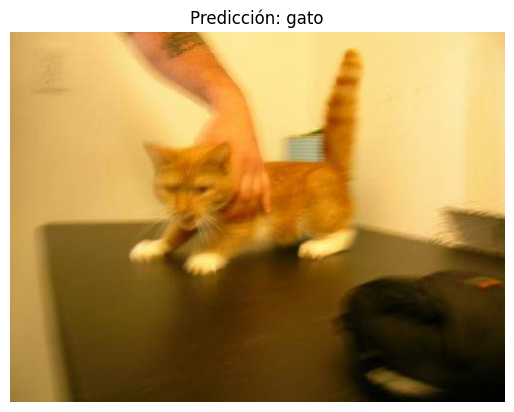

Valor de predicción: 0.39482957


In [43]:
img_path = "../data/dogs-vs-cats/proof/cat.0.jpg"
 # Cambio la ruta a una imagen de prueba

def predict_image(model, img_path):
    img = load_img(img_path, target_size=(200,200))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)[0][0]

    if pred > 0.5:
        label = "perro "
    else:
        label = "gato"

    plt.imshow(load_img(img_path))
    plt.title(f"Predicción: {label}")
    plt.axis('off')
    plt.show()

    print("Valor de predicción:", pred)

# USO:
predict_image(model, img_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


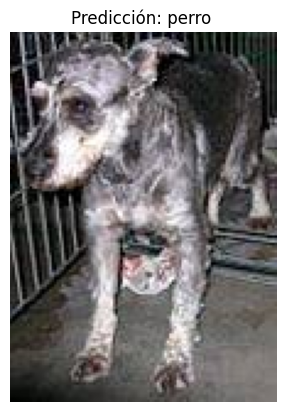

Valor de predicción: 0.66336447


In [44]:
img_path = "../data/dogs-vs-cats/proof/dog.10001.jpg"
 # Cambio la ruta a una imagen de prueba

def predict_image(model, img_path):
    img = load_img(img_path, target_size=(200,200))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)[0][0]

    if pred > 0.5:
        label = "perro "
    else:
        label = "gato"

    plt.imshow(load_img(img_path))
    plt.title(f"Predicción: {label}")
    plt.axis('off')
    plt.show()

    print("Valor de predicción:", pred)

# USO:
predict_image(model, img_path)

In [ ]:
with open('/workspaces/GuilloMansa-MachineLearning/models/11-Image-Classifier.pkl', 'wb') as file:
    pickle.dump(model, file)

NameError: name 'model' is not defined